# Aqui implementarei o algoritmo K-Nearest Neighbors para classificação multinomial do dataset MNIST - Hand digits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# importando a biblioteca com varios datasets nativos e prontos para análise
from sklearn.datasets import fetch_openml
np.random.seed(42)

In [3]:
# Carregando os dados
mnist = fetch_openml('mnist_784')

In [4]:
# O arquivo vem em forma de dicionário, para pegar os dados que queremos:
x, y = mnist['data'], mnist['target']

In [5]:
# Temos um dataset com 70 mil imagens,
# onde cada uma possui tamanho 28x28 pixels em apenas 1 CH, preto e branco.
print(x.shape) 
print(y.shape)

(70000, 784)
(70000,)


In [9]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

# Separando os dados
60mil imagens são de treinamento, enquanto as outras 10mil são para teste.
dessas 60 mil, vamos tirar 5 mil para validação e deixar as 10 mil para teste.

In [13]:
xtr, xte, xval, ytr, yte, yval = x[:55000,:], x[60000:,:], x[55000:60000], y[:55000], y[60000:], y[55000:60000]

In [14]:
print(xtr.shape)
print(xte.shape)
print(xval.shape)
print(ytr.shape)
print(yte.shape)
print(yval.shape)

(55000, 784)
(10000, 784)
(5000, 784)
(55000,)
(10000,)
(5000,)


# Treinando o modelo
Agora vamos treinar nosso KNN:

In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
knn = KNeighborsClassifier(n_neighbors=3)

In [17]:
knn.fit(xtr, ytr)

KNeighborsClassifier(n_neighbors=3)

# Medindo a Performance
Agora vamos medir a performance de diferentes formas, considerando que é um sistema de classificação multiclasse

In [18]:
pred = knn.predict(xval)

In [20]:
# Confusion Matrix e Classification Report
from sklearn.metrics import confusion_matrix as cm, classification_report as cr
pred

array(['1', '2', '8', ..., '5', '6', '8'], dtype=object)

In [23]:
print('Confusion Matrix :')
print(cm(yval, pred))
print('\n')
print('Classification Report')
print(cr(yval, pred))

Confusion Matrix :
[[485   0   1   0   0   0   1   0   0   2]
 [  0 530   0   0   0   0   0   0   0   0]
 [  2   2 483   1   0   1   0   4   0   0]
 [  0   0   2 498   0   4   1   1   3   0]
 [  0   6   0   0 486   0   0   1   0   6]
 [  1   0   1  13   0 434   7   0   1   1]
 [  0   0   0   0   0   0 482   0   0   0]
 [  0   3   0   0   3   0   0 556   0   1]
 [  1   4   2   0   1   9   0   2 473   2]
 [  0   1   1   7   6   2   0   2   0 464]]


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       489
           1       0.97      1.00      0.99       530
           2       0.99      0.98      0.98       493
           3       0.96      0.98      0.97       509
           4       0.98      0.97      0.98       499
           5       0.96      0.95      0.96       458
           6       0.98      1.00      0.99       482
           7       0.98      0.99      0.98       563
           8       0.99      0.96      

# Escolhendo o melhor K

In [14]:
error_rate = []

# Will take some time
import time
from datetime import timedelta
start_time = time.monotonic()

for i in range(1,20):
    print('loop %s'%i)
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtr,ytr)
    pred_i = knn.predict(xval)
    error_rate.append(np.mean(pred_i != yval))

end_time = time.monotonic()
print(timedelta(seconds=end_time - start_time))

loop 1
loop 2
loop 3
loop 4
loop 5
loop 6
loop 7
loop 8
loop 9
loop 10
loop 11
loop 12
loop 13
loop 14
loop 15
loop 16
loop 17
loop 18
loop 19
3:40:27.906000


Text(0, 0.5, 'Error Rate')

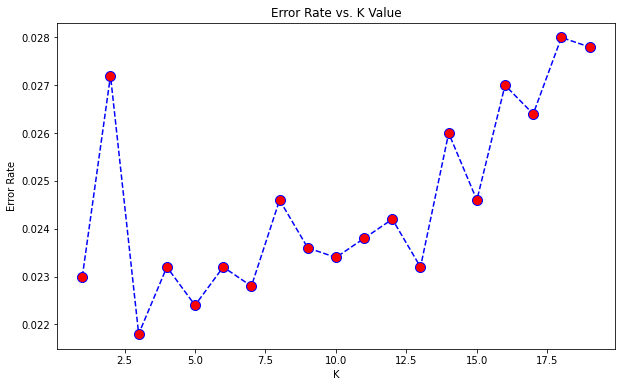

In [15]:
plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [16]:
bestK = min(error_rate)

In [25]:
BestKNN = KNeighborsClassifier(n_neighbors=3)
BestKNN.fit(xtr, ytr)
Bestpred = BestKNN.predict(xte)

In [27]:
print('Confusion Matrix :')
print(cm(yte, Bestpred))
print('\n')
print('Classification Report')
print(cr(yte, Bestpred))

Confusion Matrix :
[[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1134    1    0    0    0    0    0    0    0]
 [  10    8  994    3    1    0    0   15    1    0]
 [   0    3    3  976    1   11    1    7    4    4]
 [   2    6    0    0  948    0    4    2    0   20]
 [   6    1    0   14    2  856    4    1    3    5]
 [   5    3    0    0    3    3  944    0    0    0]
 [   0   20    5    0    3    0    0  990    0   10]
 [   8    2    4   15    8   13    3    5  912    4]
 [   6    5    2    7    9    3    1    6    1  969]]


Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98    

In [30]:
Bestpred[10]

'0'

In [31]:
yte[10]

'0'

In [ ]:
import joblib

In [ ]:
nome_arquivo = 'knn_mnist(nb).sav'

In [ ]:
joblib.dump(BestKNN, nome_arquivo)

In [ ]:
#loaded_model = joblib.load('knn_mnist.sav')
#result = loaded_model.score(xval, yval)
#print(result)